# Baseline Fraud Model - Selected Dataset

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / "app").is_dir():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
 )
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from app.ml.preprocessing import (
    build_preprocessor,
    prepare_features_and_target,
 )

In [2]:
DATA_PATH = Path("../data/processed/bank_fraud_poc_sample.csv")

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (100000, 26)


,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,...,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type
0,TXN0000000001,CUST00121959,2023-08-17,21:13:00,21,0,0,USA,London,Grocery,...,39.49,157,23,52.7,10.20,0,0,0,0,NaN
1,TXN0000000010,CUST00087499,2020-03-30,21:08:00,21,0,0,Mexico,Mumbai,Crypto Exchange,...,139.81,154,29,1.2,16.54,0,0,0,0,NaN
2,TXN0000000017,CUST00067222,2023-08-28,03:03:00,3,0,1,USA,London,Fuel,...,169.83,145,22,32.0,6.46,0,0,0,0,NaN
3,TXN0000000021,CUST00194028,2021-01-23,06:03:00,6,1,1,USA,Manchester,Online Shopping,...,31.09,127,16,2.2,4.88,0,0,0,0,NaN
4,TXN0000000028,CUST00159766,2021-06-09,02:31:00,2,0,1,Japan,São Paulo,Crypto Exchange,...,26.33,136,26,0.9,1.23,1,5,0,1,Synthetic Identity


## Prepare Features and Target

In [3]:
X, y = prepare_features_and_target(df)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(y.value_counts(normalize=True) * 100)

Features shape: (100000, 20)
Target shape: (100000,)

Feature columns:
['hour_of_day', 'is_weekend', 'is_night_transaction', 'country', 'city', 'merchant_category', 'payment_method', 'device_type', 'customer_age', 'credit_score', 'account_age_years', 'account_balance', 'transaction_amount', 'num_prev_transactions', 'transaction_freq_monthly', 'distance_from_home_km', 'time_since_last_txn_hrs', 'is_international', 'failed_attempts', 'pin_changed_recently']

Target distribution:
is_fraud
0    94474
1     5526
Name: count, dtype: int64

Target percentage:
is_fraud
0    94.474
1     5.526
Name: proportion, dtype: float64


## Train Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest distribution:")
print(y_test.value_counts(normalize=True) * 100)

Train shape: (80000, 20)
Test shape: (20000, 20)

Train distribution:
is_fraud
0    94.47375
1     5.52625
Name: proportion, dtype: float64

Test distribution:
is_fraud
0    94.475
1     5.525
Name: proportion, dtype: float64


## Build Baseline Pipeline

In [5]:
preprocessor = build_preprocessor(
    X_train,
    scale_numeric=True,
)

baseline_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
)

baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", baseline_model),
    ]
)

## Train Baseline Model

In [6]:
baseline_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['hour_of_day','is_weekend','is_night_transaction',...,'is_international', 'failed_attempts','pin_changed_recently']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transform

## Generate Predictions

In [7]:
y_pred = baseline_pipeline.predict(X_test)

y_probability = baseline_pipeline.predict_proba(X_test)[:, 1]

## Baseline Metrics

In [8]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probability)

baseline_results = pd.DataFrame(
    [
        {
            "Model": "Logistic Regression",
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "ROC_AUC": roc_auc,
        }
    ]
)

baseline_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.72015,0.109391,0.569231,0.183516,0.710641


In [9]:
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1       : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.7201
Precision: 0.1094
Recall   : 0.5692
F1       : 0.1835
ROC-AUC  : 0.7106


## Classification Report

In [10]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Legitimate",
            "Fraudulent",
        ],
    )
)

              precision    recall  f1-score   support

  Legitimate       0.97      0.73      0.83     18895
  Fraudulent       0.11      0.57      0.18      1105

    accuracy                           0.72     20000
   macro avg       0.54      0.65      0.51     20000
weighted avg       0.92      0.72      0.80     20000



## Confusion Matrix

[[13774  5121]
 [  476   629]]


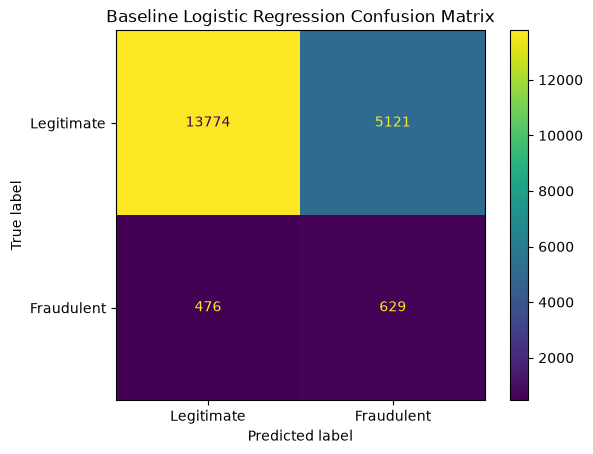

In [11]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Legitimate",
        "Fraudulent",
    ],
).plot()

plt.title("Baseline Logistic Regression Confusion Matrix")
plt.show()

## Baseline Model Results